# 1. Project Overview 
This project analyzes the relationship between salary, education, and occupation across U.S. states using data from the Bureau of Labor Statistics (BLS) and the U.S. Census. The goal is to understand how these factors influence job opportunities and income levels in different geographical areas.

# 2.  Data Preparation


In [2]:
# loading libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
sns.set()


## BLS Data Preparation

In [3]:
# Load the data using pandas
bls_data=pd.read_excel("./Ressources/bls_state_data.xlsx")
# Preview the first few rows to check if the data is being read correctly
display(bls_data.head(3))

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,19.88,30.09,46.18,22620,29580,41350,62580,96050,NaN,NaN
1,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,47.95,67.22,95.44,50710,73180,99740,139810,198520,NaN,NaN
2,1,Alabama,2,AL,0,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,79.48,102.01,#,65700,123960,165320,212180,#,NaN,NaN


In [4]:
#Preview the last 5 lines of the file
display(bls_data.tail(3))

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
37673,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7062,"Laborers and Freight, Stock, and Material Move...",...,15.53,17.65,19.42,26520,28920,32300,36720,40390,NaN,NaN
37674,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7064,"Packers and Packagers, Hand",...,11.56,14.33,17.29,22450,22880,24040,29810,35950,NaN,NaN
37675,78,Virgin Islands,3,VI,0,Cross-industry,cross-industry,1235,53-7065,Stockers and Order Fillers,...,13.12,13.76,16.4,22460,23610,27290,28630,34110,NaN,NaN


In [5]:
# check the columns names:
bls_data.columns

Index(['AREA', 'AREA_TITLE', 'AREA_TYPE', 'PRIM_STATE', 'NAICS', 'NAICS_TITLE',
       'I_GROUP', 'OWN_CODE', 'OCC_CODE', 'OCC_TITLE', 'O_GROUP', 'TOT_EMP',
       'EMP_PRSE', 'JOBS_1000', 'LOC_QUOTIENT', 'PCT_TOTAL', 'PCT_RPT',
       'H_MEAN', 'A_MEAN', 'MEAN_PRSE', 'H_PCT10', 'H_PCT25', 'H_MEDIAN',
       'H_PCT75', 'H_PCT90', 'A_PCT10', 'A_PCT25', 'A_MEDIAN', 'A_PCT75',
       'A_PCT90', 'ANNUAL', 'HOURLY'],
      dtype='object')

In [6]:
# Select the relevant columns from the DataFrame
relevant_columns = [
    'AREA_TITLE', 'PRIM_STATE', 'LOC_QUOTIENT', 'OCC_CODE', 'OCC_TITLE','TOT_EMP','JOBS_1000',
    'H_MEAN', 'A_MEAN'
]
# Subset the DataFrame 
bls_data = bls_data[relevant_columns]
bls_data.head()

,AREA_TITLE,PRIM_STATE,LOC_QUOTIENT,OCC_CODE,OCC_TITLE,TOT_EMP,JOBS_1000,H_MEAN,A_MEAN
0,Alabama,AL,1,00-0000,All Occupations,2053090,1000,25.67,53400
1,Alabama,AL,0.74,11-0000,Management Occupations,105580,51.424,56.21,116920
2,Alabama,AL,0.25,11-1011,Chief Executives,720,0.348,106.26,221030
3,Alabama,AL,0.73,11-1021,General and Operations Managers,34450,16.781,62.17,129310
4,Alabama,AL,2.6,11-1031,Legislators,1140,0.555,*,33690


In [7]:
#check the dtypes of the df
bls_data.dtypes

AREA_TITLE      object
PRIM_STATE      object
LOC_QUOTIENT    object
OCC_CODE        object
OCC_TITLE       object
TOT_EMP         object
JOBS_1000       object
H_MEAN          object
A_MEAN          object
dtype: object

In [8]:
#create a copy of the original data Frame
bls_df=bls_data.copy()
# Convert numeric columns to appropriate types (handle errors in conversion)
numeric_columns = ['LOC_QUOTIENT','TOT_EMP', 'H_MEAN', 'A_MEAN','JOBS_1000']
# Convert specified columns to numeric, handling errors with 'coerce'
bls_df[numeric_columns] = bls_df[numeric_columns].apply(pd.to_numeric, errors='coerce')
# Preview the cleaned data
bls_df.head()


,AREA_TITLE,PRIM_STATE,LOC_QUOTIENT,OCC_CODE,OCC_TITLE,TOT_EMP,JOBS_1000,H_MEAN,A_MEAN
0,Alabama,AL,1.00,00-0000,All Occupations,2053090.0,1000.000,25.67,53400.0
1,Alabama,AL,0.74,11-0000,Management Occupations,105580.0,51.424,56.21,116920.0
2,Alabama,AL,0.25,11-1011,Chief Executives,720.0,0.348,106.26,221030.0
3,Alabama,AL,0.73,11-1021,General and Operations Managers,34450.0,16.781,62.17,129310.0
4,Alabama,AL,2.60,11-1031,Legislators,1140.0,0.555,NaN,33690.0


In [9]:
#recheck the data type
bls_df.dtypes

AREA_TITLE       object
PRIM_STATE       object
LOC_QUOTIENT    float64
OCC_CODE         object
OCC_TITLE        object
TOT_EMP         float64
JOBS_1000       float64
H_MEAN          float64
A_MEAN          float64
dtype: object

In [10]:
#  Ensure that AREA_TITLE, and OCC_TITLE have consistent formatting 
#str.strip to Remove leading/trailing spaces and str.title to standardize case
bls_df.loc[:,'AREA_TITLE'] = bls_df['AREA_TITLE'].str.strip().str.title()#strip spaces and standardize text formatting 
bls_df.loc[:,'OCC_TITLE'] = bls_df['OCC_TITLE'].str.strip().str.title()


In [11]:
# Remove hyphen and the invalid code from the OCC_CODE column
bls_df.loc[:,'OCC_CODE'] = bls_df['OCC_CODE'].str.replace('-', '', regex=False).replace('', np.nan).dropna()

In [12]:
# Get the unique values for each column in the DataFrame
unique_values = bls_df.apply(lambda x: x.unique())
# Display the unique values for each column
print(unique_values)

AREA_TITLE      [Alabama, Alaska, Arizona, Arkansas, Californi...
PRIM_STATE      [AL, AK, AZ, AR, CA, CO, CT, DE, DC, FL, GA, H...
LOC_QUOTIENT    [1.0, 0.74, 0.25, 0.73, 2.6, 0.24, 0.3, 0.47, ...
OCC_CODE        [000000, 110000, 111011, 111021, 111031, 11201...
OCC_TITLE       [All Occupations, Management Occupations, Chie...
TOT_EMP         [2053090.0, 105580.0, 720.0, 34450.0, 1140.0, ...
JOBS_1000       [1000.0, 51.424, 0.348, 16.781, 0.555, 0.032, ...
H_MEAN          [25.67, 56.21, 106.26, 62.17, nan, 53.99, 62.9...
A_MEAN          [53400.0, 116920.0, 221030.0, 129310.0, 33690....
dtype: object


In [13]:
#check and count the missing values
missing_values=bls_df.isna().sum()
missing_values

AREA_TITLE         0
PRIM_STATE         0
LOC_QUOTIENT     899
OCC_CODE           0
OCC_TITLE          0
TOT_EMP          899
JOBS_1000        899
H_MEAN          3179
A_MEAN           708
dtype: int64

In [14]:
#drop all the missing values from  the data
bls_df=bls_df.dropna(how='any')
# check all the remove values
bls_df.shape
# bls_df.isna().sum()

(33559, 9)

In [15]:
# ensure to keep only the 50 us state while excluding the others 
unwanted_state=['GU','PR','VI','DC']
bls_clean=bls_df[~bls_df['PRIM_STATE'].isin(unwanted_state)]
#check the length of the cleaned state
bls_clean['PRIM_STATE'].nunique()

50

In [16]:
# filter dataset to include only rows where the annual mean wage (A_MEAN) or hourly wage (H_MEAN) exceeds the equivalent of $100K per year.
bls_clean = bls_clean[(bls_clean['A_MEAN'] >= 100000) | (bls_clean['H_MEAN'] >= 48.08)]
bls_clean.tail(5)

,AREA_TITLE,PRIM_STATE,LOC_QUOTIENT,OCC_CODE,OCC_TITLE,TOT_EMP,JOBS_1000,H_MEAN,A_MEAN
36328,Wyoming,WY,0.72,291229,"Physicians, All Other",400.0,1.463,163.24,339540.0
36330,Wyoming,WY,1.27,291249,"Surgeons, All Other",60.0,0.221,191.58,398480.0
36437,Wyoming,WY,0.48,414011,"Sales Representatives, Wholesale And Manufactu...",270.0,0.990,60.70,126250.0
36527,Wyoming,WY,30.92,475043,"Roof Bolters, Mining",110.0,0.400,51.77,107670.0
36590,Wyoming,WY,3.65,518012,Power Distributors And Dispatchers,60.0,0.217,52.37,108940.0


In [17]:
# check  the type after data split
bls_clean.dtypes

AREA_TITLE       object
PRIM_STATE       object
LOC_QUOTIENT    float64
OCC_CODE         object
OCC_TITLE        object
TOT_EMP         float64
JOBS_1000       float64
H_MEAN          float64
A_MEAN          float64
dtype: object

In [18]:
# Summary statistics for numerical columns
bls_clean.describe()

,LOC_QUOTIENT,TOT_EMP,JOBS_1000,H_MEAN,A_MEAN
count,4259.000000,4.259000e+03,4259.000000,4259.000000,4259.000000
mean,1.103677,1.042200e+04,2.761861,71.987614,149733.226109
std,1.110601,5.237435e+04,9.314721,32.439480,67474.253219
min,0.030000,3.000000e+01,0.005000,48.080000,100000.000000
25%,0.640000,2.900000e+02,0.144000,53.030000,110305.000000
50%,0.920000,1.090000e+03,0.534000,59.770000,124330.000000
75%,1.250000,4.560000e+03,1.625000,73.490000,152865.000000
max,30.920000,1.308800e+06,96.707000,279.590000,581560.000000


In [19]:
# check the data structure
bls_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4259 entries, 1 to 36590
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   AREA_TITLE    4259 non-null   object 
 1   PRIM_STATE    4259 non-null   object 
 2   LOC_QUOTIENT  4259 non-null   float64
 3   OCC_CODE      4259 non-null   object 
 4   OCC_TITLE     4259 non-null   object 
 5   TOT_EMP       4259 non-null   float64
 6   JOBS_1000     4259 non-null   float64
 7   H_MEAN        4259 non-null   float64
 8   A_MEAN        4259 non-null   float64
dtypes: float64(5), object(4)
memory usage: 332.7+ KB


In [71]:
# Save the cleaned data to a CSV file
bls_clean.to_csv('./Data/bls_data.csv', index=False)

## Census Data Preparation

In [40]:
#load data
census_data = pd.read_csv("./Ressources/census_data.csv",delimiter=',')
# check data
census_data.head()

,YEAR,REGION,STATEICP,SEX,AGE,EDUC,EDUCD,GRADEATT,GRADEATTD,DEGFIELD,...,OCCSOC,IND,INDNAICS,INCTOT,INCWAGE,OCCSCORE,PWSTATE2,US2022C_WAGP,US2022C_OCCP,US2022C_POWSP
0,2022,32,41,1,25,10,101,7,70,54,...,131111,7870,611M1,6313,6313,45,1,5400,710,1
1,2022,32,41,1,25,10,101,7,70,54,...,131111,7870,611M1,6313,6313,45,1,5400,710,1
2,2022,32,41,1,25,10,101,7,70,54,...,131111,7870,611M1,6313,6313,45,1,5400,710,1
3,2022,32,41,2,24,10,101,7,70,64,...,399041,7870,611M1,11691,11691,13,1,10000,4640,1
4,2022,32,41,1,25,10,101,7,70,54,...,131111,7870,611M1,6313,6313,45,1,5400,710,1


In [41]:
#Check the columns names
census_data.columns

Index(['YEAR', 'REGION', 'STATEICP', 'SEX', 'AGE', 'EDUC', 'EDUCD', 'GRADEATT',
       'GRADEATTD', 'DEGFIELD', 'DEGFIELDD', 'OCC', 'OCCSOC', 'IND',
       'INDNAICS', 'INCTOT', 'INCWAGE', 'OCCSCORE', 'PWSTATE2', 'US2022C_WAGP',
       'US2022C_OCCP', 'US2022C_POWSP'],
      dtype='object')

In [42]:
# Filter for individuals earning $100K or more
census_data= census_data[census_data['INCTOT'] >= 100000]

In [43]:
# filtre the data  to only keep the relevant columns
relevant_c = ['STATEICP' ,'DEGFIELDD', 'EDUCD','OCCSOC','INCTOT','SEX', 'AGE']
census_data=census_data[relevant_c]
census_data.head()

,STATEICP,DEGFIELDD,EDUCD,OCCSOC,INCTOT,SEX,AGE
12,41,2417,101,112022,247841,1,47
13,41,4101,114,551010,112230,1,43
14,41,5901,101,1191XX,149640,2,54
15,41,3401,101,113061,104046,1,36
21,41,6004,114,119030,457102,2,54


In [44]:
# Remove any non-numeric characters and ensure all codes are exactly 6 digits by padding with leading zeros
census_data.loc[:, 'OCCSOC'] = census_data['OCCSOC'].str.extract('(\d+)', expand=False).str.zfill(6)

In [45]:
#Replace all occurrences of 1 with "Male" and 2 with "Female" in the SEX column.#
census_data.loc[:,'SEX'] = census_data['SEX'].astype(str).replace({'1': 'Male', '2': 'Female'})

C:\Users\marwa\AppData\Local\Temp\ipykernel_3832\1833119181.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['Male' 'Male' 'Female' ... 'Male' 'Female' 'Male']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  census_data.loc[:,'SEX'] = census_data['SEX'].astype(str).replace({'1': 'Male', '2': 'Female'})


In [46]:
# Display the data Structure 
census_data.head()

,STATEICP,DEGFIELDD,EDUCD,OCCSOC,INCTOT,SEX,AGE
12,41,2417,101,112022,247841,Male,47
13,41,4101,114,551010,112230,Male,43
14,41,5901,101,001191,149640,Female,54
15,41,3401,101,113061,104046,Male,36
21,41,6004,114,119030,457102,Female,54


In [47]:
# Dictionary to map STATEICP codes to state names (50 U.S. states only)
census_df=census_data.copy()
state_map = {
    1: 'Connecticut', 2: 'Maine', 3: 'Massachusetts', 4: 'New Hampshire',
    5: 'Rhode Island', 6: 'Vermont', 11: 'Delaware', 12: 'New Jersey',
    13: 'New York', 14: 'Pennsylvania', 21: 'Illinois', 22: 'Indiana',
    23: 'Michigan', 24: 'Ohio', 25: 'Wisconsin', 31: 'Iowa', 32: 'Kansas',
    33: 'Minnesota', 34: 'Missouri', 35: 'Nebraska', 36: 'North Dakota',
    37: 'South Dakota', 40: 'Virginia', 41: 'Alabama', 42: 'Arkansas',
    43: 'Florida', 44: 'Georgia', 45: 'Louisiana', 46: 'Mississippi',
    47: 'North Carolina', 48: 'South Carolina', 49: 'Texas', 51: 'Kentucky',
    52: 'Maryland', 53: 'Oklahoma', 54: 'Tennessee', 56: 'West Virginia',
    61: 'Arizona', 62: 'Colorado', 63: 'Idaho', 64: 'Montana', 65: 'Nevada',
    66: 'New Mexico', 67: 'Utah', 68: 'Wyoming', 71: 'California',
    72: 'Oregon', 73: 'Washington', 81: 'Alaska', 82: 'Hawaii'
}
# apply the map on the Data
census_df.loc[:,'STATE']=census_df['STATEICP'].map(state_map)


In [48]:
# Education map for the provided codes
education_map = {

    101: "Bachelor's degree", 
    114: "Master's degree", 
    115: "Professional degree", 
    116: "Doctoral degree", 
}

# Apply the mapping again
census_df['EDUCATION_LABEL'] = census_df['EDUCD'].map(education_map)

In [49]:
degree_field_map = {
    1100: "Agriculture", 1101: "Agriculture Production and Management", 1102: "Agricultural Economics", 1103: "Animal Sciences", 1104: "Food Science",
    1105: "Plant Science", 1106: "Soil Science", 1199: "Miscellaneous Agriculture", 
    1301: "Environmental Science", 1302: "Forestry", 1303: "Natural Resources Management", 
    1401: "Architecture", 
    1501: "Area, Ethnic, and Civilization Studies", 
    1901: "Communications", 1902: "Journalism", 1903: "Mass Media", 1904: "Advertising and Public Relations", 
    2001: "Communication Technologies", 
    2100: "Computer Science and IT", 2101: "Computer Programming", 2102: "Computer Science", 2105: "Information Sciences", 
    2106: "Information Security", 2107: "Computer Networking", 
    2201: "Cosmetology and Culinary Arts", 
    2300: "Education", 2301: "Educational Administration", 2303: "School Counseling", 2304: "Elementary Education", 
    2305: "Mathematics Education", 2306: "Physical and Health Education", 2307: "Early Childhood Education", 
    2308: "Science Education", 2309: "Secondary Education", 2310: "Special Education", 2311: "Social Science Education", 
    2312: "Teacher Education", 2313: "Language and Drama Education", 2314: "Art and Music Education", 2399: "Miscellaneous Education", 
    2400: "Engineering", 2401: "Aerospace Engineering", 2402: "Biological Engineering", 2403: "Architectural Engineering", 
    2404: "Biomedical Engineering", 2405: "Chemical Engineering", 2406: "Civil Engineering", 2407: "Computer Engineering", 
    2408: "Electrical Engineering", 2409: "Environmental Engineering", 2410: "Industrial Engineering", 2411: "Materials Engineering", 
    2412: "Mechanical Engineering", 2413: "Metallurgical Engineering", 2414: "Mining Engineering", 2415: "Naval Architecture", 
    2416: "Nuclear Engineering", 2417: "Petroleum Engineering", 2418: "Miscellaneous Engineering", 2419: "Robotics Engineering", 
    2499: "Engineering Technologies", 2500: "Engineering Tech: General", 2501: "Drafting and Design", 2502: "Electrical Engineering Tech", 
    2503: "Industrial Production Tech", 2504: "Mechanical Engineering Tech", 2599: "Miscellaneous Engineering Tech", 
    2601: "Biology", 2602: "Biochemistry", 2603: "Botany", 
    2901: "Mathematics", 3000: "Statistics", 3301: "Social Work", 3302: "Public Administration", 
    3401: "Physical Sciences", 3402: "Astronomy", 3600: "Chemistry", 3601: "Geology", 3602: "Geosciences", 3603: "Oceanography", 
    3604: "Physics", 3605: "Meteorology", 3606: "Planetary Science", 3607: "Materials Science", 3608: "Atmospheric Science", 
    3609: "Environmental Science", 3611: "Space Science", 3699: "Misc. Physical Sciences", 
    3700: "Social Sciences", 3701: "Anthropology", 3702: "Archaeology", 
    3801: "Philosophy and Religion", 
    4000: "Economics", 4001: "Sociology", 4002: "Political Science", 4005: "Geography", 4006: "Criminal Justice", 
    4007: "Public Policy", 4801: "Law and Legal Studies", 
    5000: "Liberal Arts", 5001: "English Literature", 5002: "Linguistics", 5003: "Foreign Languages", 5004: "Comparative Literature", 
    5005: "Philosophy", 5006: "Religious Studies", 5007: "Humanities", 5008: "Interdisciplinary Humanities", 5098: "Miscellaneous Humanities", 
    5102: "Music", 5200: "Fine Arts", 5201: "Design and Applied Arts", 5202: "Graphic Design", 5203: "Photography", 5205: "Film", 5206: "Theater Arts", 
    5299: "Miscellaneous Fine Arts", 
    5401: "Business", 5402: "Accounting", 5403: "Finance", 5404: "Human Resources", 
    5500: "Management Information Systems", 5501: "Marketing", 5502: "Management Science", 5503: "Supply Chain Management", 
    5504: "Real Estate", 5505: "Entrepreneurship", 5506: "International Business", 5507: "Business Administration", 5599: "Miscellaneous Business", 
    5601: "Consumer Sciences", 5701: "Public Health", 
    6000: "Nursing", 6001: "Pharmacy", 6002: "Health Administration", 6003: "Public Health", 6004: "Medical Assisting", 
    6005: "Clinical Sciences", 6006: "Veterinary Sciences", 6007: "Health Services", 6099: "Miscellaneous Health Professions", 
    6100: "General Medicine", 6102: "Dentistry", 6103: "Pharmacy Technician", 6104: "Radiological Sciences", 6199: "Miscellaneous Medical Sciences", 
    6105: "Biomedical Sciences", 6106: "Nutritional Science", 6107: "Athletic Training", 6108: "Therapeutic Sciences", 
    6109: "Mental Health Services", 6110: "Community Health Services", 
    6200: "Psychology", 6201: "Clinical Psychology", 6202: "Industrial Psychology", 6203: "Developmental Psychology", 
    6204: "Cognitive Psychology", 6205: "Forensic Psychology", 6206: "Organizational Psychology", 6207: "Educational Psychology", 
    6209: "Experimental Psychology", 6210: "Social Psychology", 6211: "Counseling Psychology", 6212: "Abnormal Psychology", 6299: "Miscellaneous Psychology", 
    6402: "Human Development", 
    6403: "Social Work", 3202: "Military Science and Leadership", 4901: "Mechanical Engineering", 4101: "General Engineering", 
    5901: "Educational Leadership", 5301: "Business Administration", 3501: "Health Professions"
}
census_df['DEGFIELDD_NAME'] = census_df['DEGFIELDD'].map(degree_field_map)

In [50]:
# check missing  values
census_df.isna().sum()

STATEICP           0
DEGFIELDD          0
EDUCD              0
OCCSOC             0
INCTOT             0
SEX                0
AGE                0
STATE              0
EDUCATION_LABEL    0
DEGFIELDD_NAME     0
dtype: int64

In [51]:
#Drop missing valeus
census_df=census_df.dropna(how='any')

In [52]:
# rename the occupation code
census_df=census_df.rename(columns={'OCCSOC':'OCC_CODE'})

In [53]:
#check data structure
census_df.head()

,STATEICP,DEGFIELDD,EDUCD,OCC_CODE,INCTOT,SEX,AGE,STATE,EDUCATION_LABEL,DEGFIELDD_NAME
12,41,2417,101,112022,247841,Male,47,Alabama,Bachelor's degree,Petroleum Engineering
13,41,4101,114,551010,112230,Male,43,Alabama,Master's degree,General Engineering
14,41,5901,101,001191,149640,Female,54,Alabama,Bachelor's degree,Educational Leadership
15,41,3401,101,113061,104046,Male,36,Alabama,Bachelor's degree,Physical Sciences
21,41,6004,114,119030,457102,Female,54,Alabama,Master's degree,Medical Assisting


In [35]:
#save cleand census data 
census_df.to_csv('./Data/census_data.csv',index=False)

## 3. Data Merging :Combining Census and BLS Data

In [60]:

# Rename columns in the BLS DataFrame for clarity
bls_clean.rename(columns={'AREA_TITLE': 'STATE'}, inplace=True)

In [61]:
# Merge the DataFrames on OCC_CODE and STATE 
merged_df = pd.merge(census_df, bls_clean, on=['OCC_CODE', 'STATE'], how='inner')

In [62]:
# check if is there any missing values before procedding 
merged_df.isna().sum()

STATEICP            0
DEGFIELDD           0
EDUCD               0
OCC_CODE            0
Annual_Income       0
SEX                 0
AGE                 0
STATE               0
EDUCATION_LABEL     0
DEGFIELDD_NAME      0
PRIM_STATE          0
LOC_QUOTIENT        0
OCC_TITLE           0
TOT_EMP             0
JOBS_1000           0
H_MEAN              0
Annual_Mean_Wage    0
dtype: int64

In [63]:
#check the data Structure 
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10273 entries, 0 to 10272
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   STATEICP          10273 non-null  int64  
 1   DEGFIELDD         10273 non-null  int64  
 2   EDUCD             10273 non-null  int64  
 3   OCC_CODE          10273 non-null  object 
 4   Annual_Income     10273 non-null  int64  
 5   SEX               10273 non-null  object 
 6   AGE               10273 non-null  int64  
 7   STATE             10273 non-null  object 
 8   EDUCATION_LABEL   10273 non-null  object 
 9   DEGFIELDD_NAME    10273 non-null  object 
 10  PRIM_STATE        10273 non-null  object 
 11  LOC_QUOTIENT      10273 non-null  float64
 12  OCC_TITLE         10273 non-null  object 
 13  TOT_EMP           10273 non-null  float64
 14  JOBS_1000         10273 non-null  float64
 15  H_MEAN            10273 non-null  float64
 16  Annual_Mean_Wage  10273 non-null  float6

In [64]:
# display the data Statistic
merged_df.describe()

,STATEICP,DEGFIELDD,EDUCD,Annual_Income,AGE,LOC_QUOTIENT,TOT_EMP,JOBS_1000,H_MEAN,Annual_Mean_Wage
count,10273.000000,10273.000000,10273.000000,1.027300e+04,10273.000000,10273.000000,10273.000000,10273.000000,10273.000000,10273.000000
mean,42.615789,4457.860703,107.057724,1.680939e+05,41.309257,1.161845,63303.016646,6.993090,65.769981,136800.167429
std,24.468860,1751.341420,6.657895,1.051136e+05,10.944780,0.539022,91276.508070,7.223279,13.800846,28705.399697
min,1.000000,1100.000000,101.000000,1.000000e+05,19.000000,0.080000,50.000000,0.018000,48.080000,100000.000000
25%,14.000000,2408.000000,101.000000,1.148220e+05,32.000000,0.890000,7890.000000,1.678000,54.940000,114270.000000
50%,45.000000,5205.000000,101.000000,1.367800e+05,40.000000,1.030000,21870.000000,3.757000,62.970000,130970.000000
75%,71.000000,6107.000000,114.000000,1.750000e+05,49.000000,1.340000,79050.000000,10.216000,73.500000,152880.000000
max,82.000000,6403.000000,116.000000,1.098315e+06,94.000000,8.960000,448530.000000,33.810000,123.150000,256160.000000


In [65]:
merged_df.columns

Index(['STATEICP', 'DEGFIELDD', 'EDUCD', 'OCC_CODE', 'Annual_Income', 'SEX',
       'AGE', 'STATE', 'EDUCATION_LABEL', 'DEGFIELDD_NAME', 'PRIM_STATE',
       'LOC_QUOTIENT', 'OCC_TITLE', 'TOT_EMP', 'JOBS_1000', 'H_MEAN',
       'Annual_Mean_Wage'],
      dtype='object')

In [66]:
# Define the desired column order
desired_order = [
    'PRIM_STATE','STATE',   # Geographic Information
    'SEX', 'AGE', 'EDUCD', 'EDUCATION_LABEL', 'DEGFIELDD',  # Demographics and Education
    'OCC_CODE', 'OCC_TITLE',  # Occupation Details
    'Annual_Income', 'TOT_EMP', 'LOC_QUOTIENT', 'JOBS_1000',  # Employment Statistics
    'H_MEAN', 'Annual_Mean_Wage'  # Wage Information
]

# Reindex the DataFrame with the desired order
merged_df = merged_df[desired_order]

# Renaming columns for clarity (no more than two words)
rename_mapping = {
    'PRIM_STATE': 'State Abbreviation',
    'STATE': 'State',
    'SEX': 'Gender',
    'AGE': 'Age',
    'EDUCD': 'Education Code',
    'EDUCATION_LABEL': 'Education Level',
    'DEGFIELDD': 'Degree Field',
    'OCC_CODE': 'Occupation Code',
    'OCC_TITLE': 'Occupation',
    'Annual_Income': 'Annual Income',
    'TOT_EMP': 'Employment',
    'LOC_QUOTIENT': 'Location Quotient',
    'JOBS_1000': 'Jobs per 1000',
    'H_MEAN': 'Hourly Mean',
    'Annual_Mean_Wage': 'Annual Mean Wage'
}

# Apply renaming
merged_df.rename(columns=rename_mapping, inplace=True)


In [67]:
# Display the updated DataFrame columns
merged_df.columns

Index(['State Abbreviation', 'State', 'Gender', 'Age', 'Education Code',
       'Education Level', 'Degree Field', 'Occupation Code', 'Occupation',
       'Annual Income', 'Employment', 'Location Quotient', 'Jobs per 1000',
       'Hourly Mean', 'Annual Mean Wage'],
      dtype='object')

In [69]:
merged_df.head()

,State Abbreviation,State,Gender,Age,Education Code,Education Level,Degree Field,Occupation Code,Occupation,Annual Income,Employment,Location Quotient,Jobs per 1000,Hourly Mean,Annual Mean Wage
0,AL,Alabama,Male,47,101,Bachelor's degree,2417,112022,Sales Managers,247841,3650.0,0.47,1.778,66.20,137700.0
1,AL,Alabama,Male,36,101,Bachelor's degree,3401,113061,Purchasing Managers,104046,1360.0,1.30,0.665,59.61,123990.0
2,AL,Alabama,Male,39,101,Bachelor's degree,6200,111021,General And Operations Managers,116906,34450.0,0.73,16.781,62.17,129310.0
3,AL,Alabama,Male,44,101,Bachelor's degree,6212,151212,Information Security Analysts,109892,2630.0,1.11,1.281,52.61,109420.0
4,AL,Alabama,Male,42,101,Bachelor's degree,6201,113051,Industrial Production Managers,135611,3110.0,1.03,1.517,58.96,122630.0


In [70]:
# Save the cleaned data to a CSV file
merged_df.to_csv('./Data/cleaned_high_pay_data.csv', index=False)

## 4. Mapping U.S. States for Salary Analysis


### Loading Data

In [ ]:
# create the path of the data to be loaded 
shapefile_path = './us_state/us_state.shp'
# Load the shapefile into a GeoDataFrame
us_states = gpd.read_file(shapefile_path)

In [ ]:
# Check the first few rows of the data to confirm it loaded correctly
us_states.head(3)

,REGION,DIVISION,STATEFP,STATENS,GEOID,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,3,5,54,01779805,54,0400000US54,WV,West Virginia,00,G4000,A,62266513826,488918898,+38.6472854,-080.6183274,"POLYGON ((-77.75438 39.33346, -77.75422 39.333..."
1,3,5,12,00294478,12,0400000US12,FL,Florida,00,G4000,A,138965379385,45968913048,+28.3989775,-082.5143005,"MULTIPOLYGON (((-83.10874 24.62949, -83.10711 ..."
2,2,3,17,01779784,17,0400000US17,IL,Illinois,00,G4000,A,143778206717,6216848695,+40.1028754,-089.1526108,"POLYGON ((-87.89243 38.28285, -87.89334 38.282..."


 ### Merging Geospatial Data with Employment Data

In [ ]:
# The merge is performed based on the state postal abbreviations: 'STUSPS' in us_states and 'State Abbriviation' in merged_df.
merged = us_states.set_index('STUSPS').join(merged_df.set_index('State Abbreviation'), rsuffix='_merged')# 'rsuffix' is used to avoid 
#column name conflicts during the merge.

In [ ]:
#check the null value after merge
merged.isna().sum()

REGION                0
DIVISION              0
STATEFP               0
STATENS               0
GEOID                 0
GEOIDFQ               0
NAME                  0
LSAD                  0
MTFCC                 0
FUNCSTAT              0
ALAND                 0
AWATER                0
INTPTLAT              0
INTPTLON              0
geometry              0
Area Title            6
Occupation Code       6
Occupation Title      6
Total Employment      6
Hourly Mean Wage      6
Annual Mean Wage      6
Hourly Median Wage    6
Annual Median Wage    6
State Code            6
State Code 2          6
Degree Field Code     6
Education Code        6
Gender                6
Age                   6
State Name            6
State of Work         6
Education Level       6
Degree Field          6
dtype: int64

In [ ]:
#handel the missing  values
merged=merged.dropna(how='any')

In [ ]:
#check data Structure 
merged.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 135474 entries, WV to AZ
Data columns (total 33 columns):
 #   Column              Non-Null Count   Dtype   
---  ------              --------------   -----   
 0   REGION              135474 non-null  object  
 1   DIVISION            135474 non-null  object  
 2   STATEFP             135474 non-null  object  
 3   STATENS             135474 non-null  object  
 4   GEOID               135474 non-null  object  
 5   GEOIDFQ             135474 non-null  object  
 6   NAME                135474 non-null  object  
 7   LSAD                135474 non-null  object  
 8   MTFCC               135474 non-null  object  
 9   FUNCSTAT            135474 non-null  object  
 10  ALAND               135474 non-null  int64   
 11  AWATER              135474 non-null  int64   
 12  INTPTLAT            135474 non-null  object  
 13  INTPTLON            135474 non-null  object  
 14  geometry            135474 non-null  geometry
 15  Area Title       

### Calculating and Mapping Mean Annual Income by State

In [ ]:
A_income_state = (merged_df.groupby(['State Abbreviation'])['Annual Mean Wage'].mean().reset_index()).round(2)
# we will have 50 rows of data and tehre will be 1 geometry for each state and we can plot the mean income by state on  a map using geopandas 
# The resulting data can be combined with the state's geometry to plot the mean income by state using GeoPandas.

In [ ]:
# display some data 
A_income_state.head()

,State Abbreviation,Annual Mean Wage
0,AK,123731.89
1,AL,120247.89
2,AR,116088.30
3,AZ,125221.25
4,CA,138057.06


In [ ]:
# Merging Annual Income Data with US State Geometries for Mapping
geo_df=A_income_state.merge(us_states, left_on = 'State Abbreviation', right_on='STUSPS') 
# This merges the calculated mean annual income data (A_income_state) with the shapefile data (us_states) based on the state name.
# 'left_on' refers to the 'STATE_NAME' column in the A_income_state DataFrame, and 'right_on' refers to the 'NAME' column in the us_states GeoDataFrame.
# This results in a new GeoDataFrame (geo_df) that includes both the mean annual income data and the corresponding geometries (state shapes).


In [ ]:
# We then convert the merged DataFrame into a GeoDataFrame by setting the 'geometry' column to hold the spatial information.
geo_df=gpd.GeoDataFrame(geo_df,geometry=geo_df.geometry)


In [ ]:

def StatesPlot(df, income_column, cmap='viridis', label_color='black', label_size=6, title='United States Map', filename='us_map.png'):
    """
    Plots a US map based on state data and an income column.

    Parameters:
    df (GeoDataFrame): Geodataframe containing the state geometries and income data.
    income_column (str): Column name representing the data to be visualized (e.g., income levels).
    cmap (str): Color map to use for visualization.
    label_color (str): Color of the state labels.
    label_size (int): Font size of the state labels.
    title (str): Title of the plot.
    filename (str): Name of the file to save the plot.

    Returns:
    None
    """
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=(15, 10), dpi=300)
    ax.set_axis_off()  # Turn off the axis to focus on the map

    # Plot the state geometries using the income column
    df.plot(income_column, ax=ax, alpha=0.7, cmap=cmap, legend=False, linewidth=0.5)

    # Add the color bar representing income
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=df[income_column].min(), vmax=df[income_column].max()))
    sm.set_array([])  # Empty array to avoid issues with ScalarMappable
    fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, aspect=10)

    # Add the title
    plt.title(title, fontsize=16)

    # Add state names (labels) to the map
    for idx, row in df.iterrows():
        try:
            centroid = row['geometry'].centroid
            ax.text(centroid.x, centroid.y, row['STUSPS'], fontsize=label_size, ha='center', color=label_color)
        except Exception as e:
            print(f"Error labeling state {row['STUSPS']}: {e}")

    # Save the figure as a PNG file for the report
    # Append a timestamp to the filename to avoid overwriting
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    updated_filename = f"Images/{filename.split('.')[0]}_{timestamp}.png"
    plt.savefig(updated_filename, bbox_inches='tight', dpi=300)

    print(f"Map saved to {updated_filename}")

    # Show the plot
    plt.show()


<Axes: >

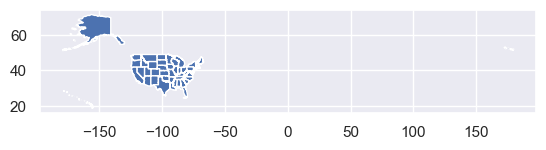

In [ ]:
geo_df.plot()

In [ ]:
test=geo_df.loc[~geo_df['STUSPS'].isin(['AK','HI'])]

Map saved to Images/us_average_income_map_20241128_024113.png


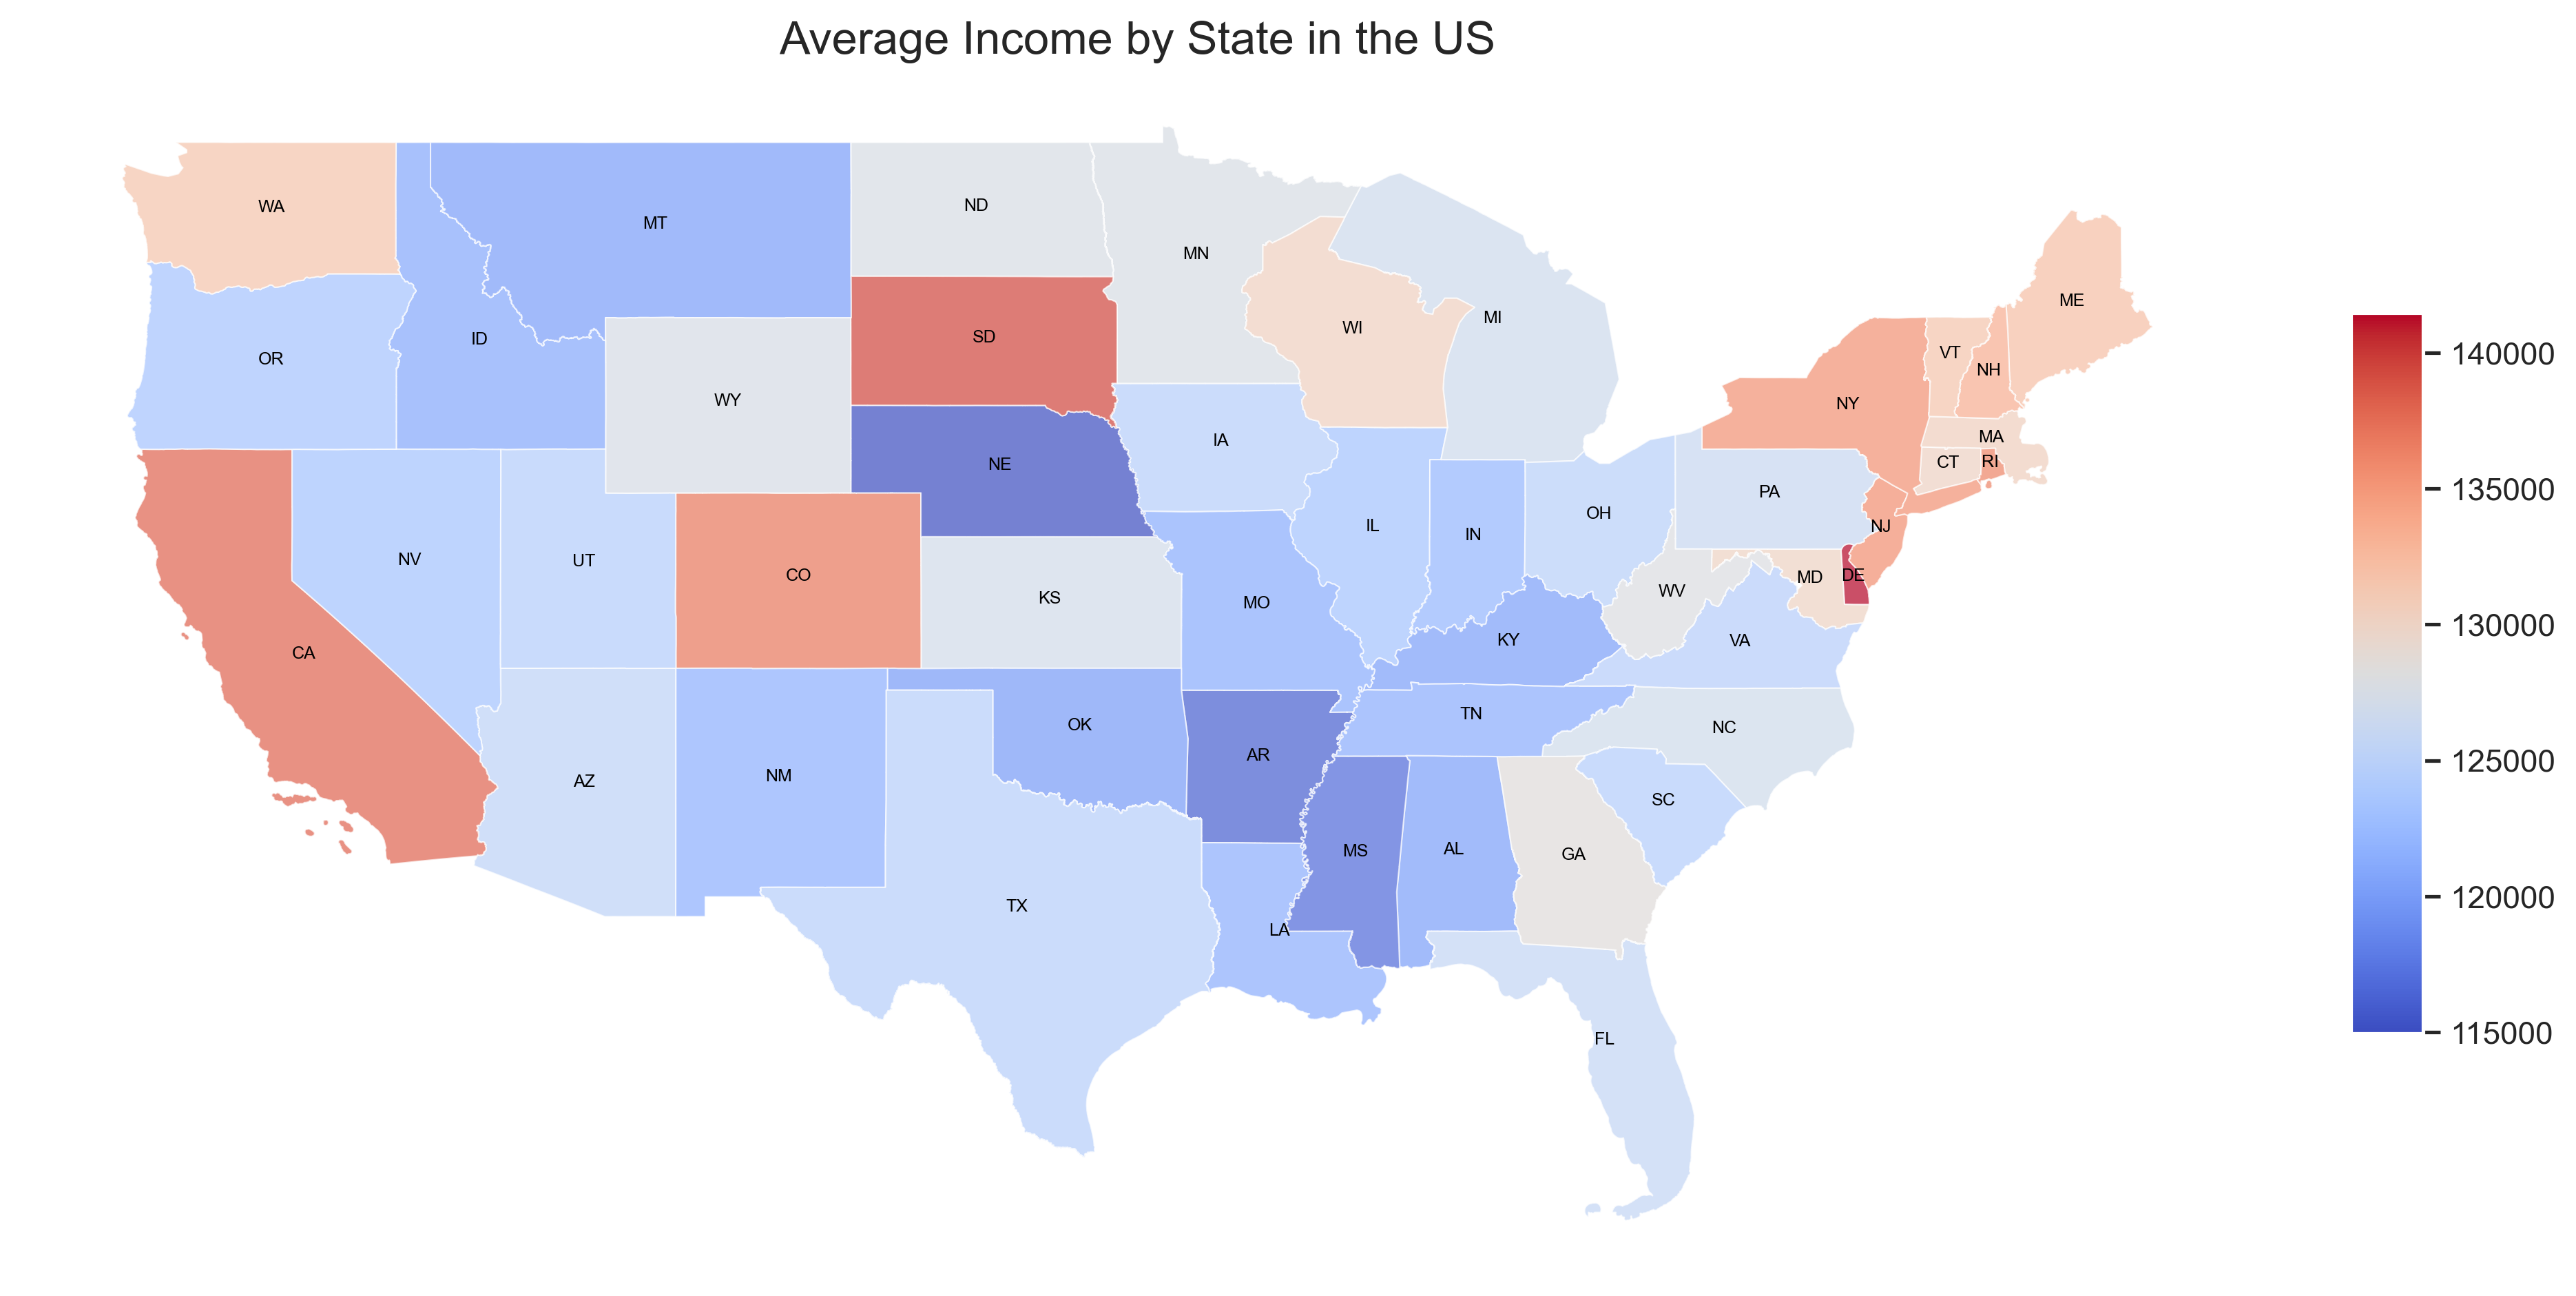

In [ ]:
# Call the fucntion
StatesPlot(test, income_column='Annual Mean Wage', cmap='coolwarm', label_color='Black', label_size=6, 
title='Average Income by State in the US', filename='us_average_income_map.png')

#### Interprutaion

Delaware has the highest concentration of high-paid individuals, based on the annual mean wage data. This distinction may be attributed to its status as a hub for corporate headquarters and financial services.

Other Top States:
- New York: With its dominance in industries such as finance, media, and technology, New York ranks second.
- California: Known for its thriving technology and entertainment sectors, California secures the third position.
- Colorado: Emerging industries like technology, aerospace, and energy significantly contribute to its high rankings.
- New Jersey: Its proximity to New York City, coupled with a robust pharmaceutical and finance sector, makes New Jersey a strong contender.
Geographic Distribution:

> States with urban centers and a strong presence of high-paying industries generally perform better. Coastal states, particularly in the Northeast and West Coast, exhibit a clear advantage over their inland counterparts.

Visualization Highlights:
- Color Intensity: Darker shades on the map represent states with higher average annual wages.
- Clusters of Wealth: States in the Mid-Atlantic and West Coast dominate, showcasing clear contrasts with less urbanized states.

Delaware leading is based on average annual wages per individual (relative concentration of high-paid individuals).


## 5. Exploratory Data Analysis

1. What is the distribution of high-paid individuals across different states?

- Plot 1: Bar plot showing the number of high-paid individuals by state.


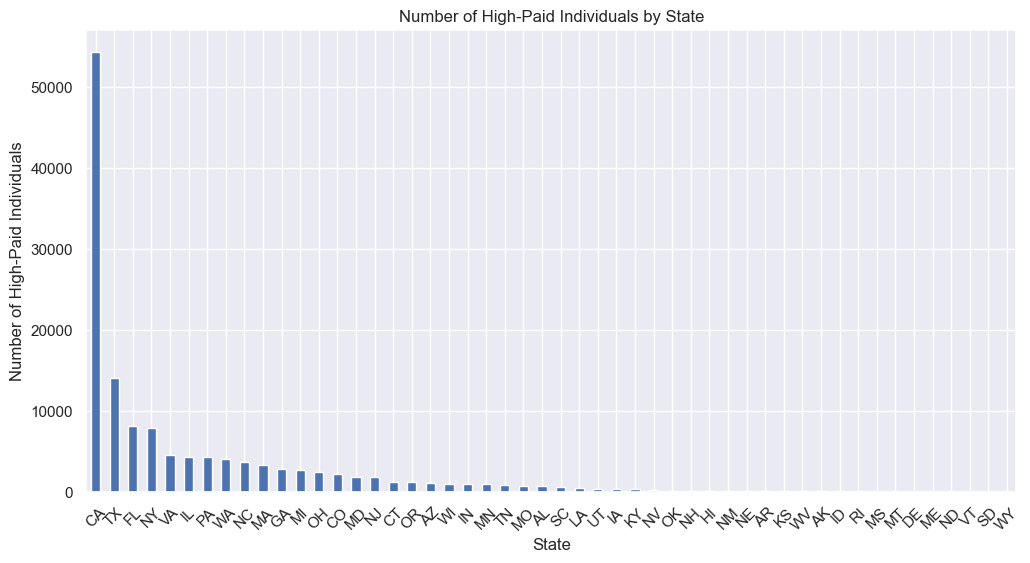

In [ ]:
# 1. Distribution of high-paid individuals across different states
# Plot 1: Bar plot
plt.figure(figsize=(12, 6))
merged_df['State Abbreviation'].value_counts().plot(kind='bar')
plt.title('Number of High-Paid Individuals by State')
plt.xlabel('State')
plt.ylabel('Number of High-Paid Individuals')
plt.xticks(rotation=45)
plt.show()

- Plot 2: Pie chart showing the percentage of high-paid individuals by state.

In [ ]:
#Group states with less than a certain threshold into "Other"
threshold = 0.05  # 5% threshold
state_counts = merged_df['State Abbreviation'].value_counts()

# Calculate the percentage of each state
state_percentages = state_counts / state_counts.sum()

# Create a new Series for states above the threshold
filtered_state_counts = state_counts[state_percentages >= threshold]

# Add "Other" category for states below the threshold
other_count = state_counts[state_percentages < threshold].sum()
if other_count > 0:
    filtered_state_counts['Other'] = other_count

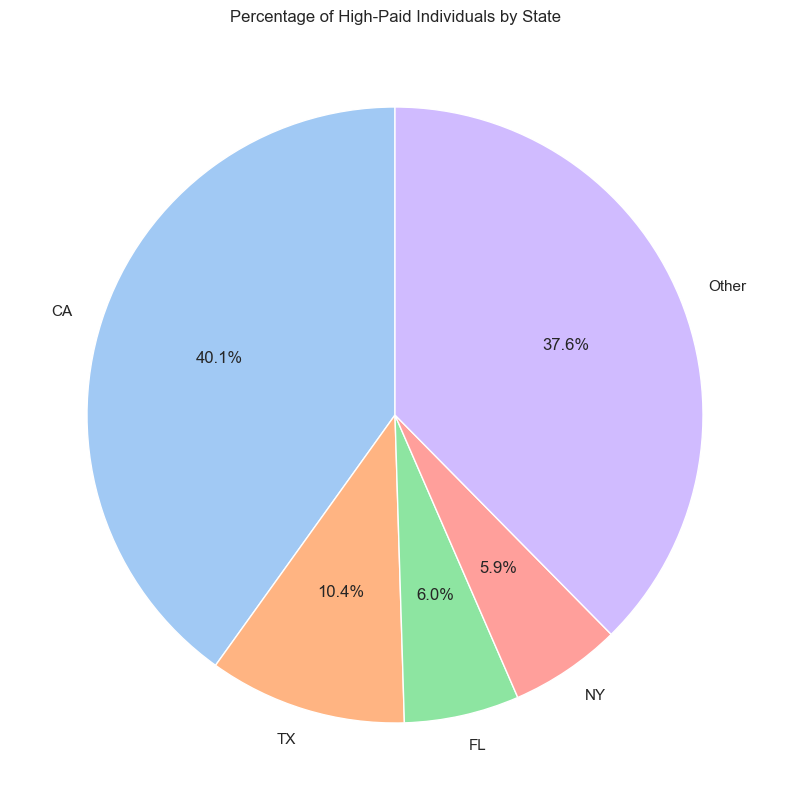

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the pie chart
plt.figure(figsize=(10, 10))
filtered_state_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("pastel"))
plt.title('Percentage of High-Paid Individuals by State')
plt.ylabel('')  # Hide the y-label
plt.show()
plt.savefig('./Images/Pie_chart_high_paid_by_state.png')

Interpretation: reflect absolute numbers of high-paid individuals due to the sheer population size of these states. For example, California has a larger population, resulting in a higher total number of high-income earners, even if the average income is not the highest.

2. What are the most common occupations among high-paid individuals?

- Plot 1: Bar plot showing the top occupations for high-paid individuals.


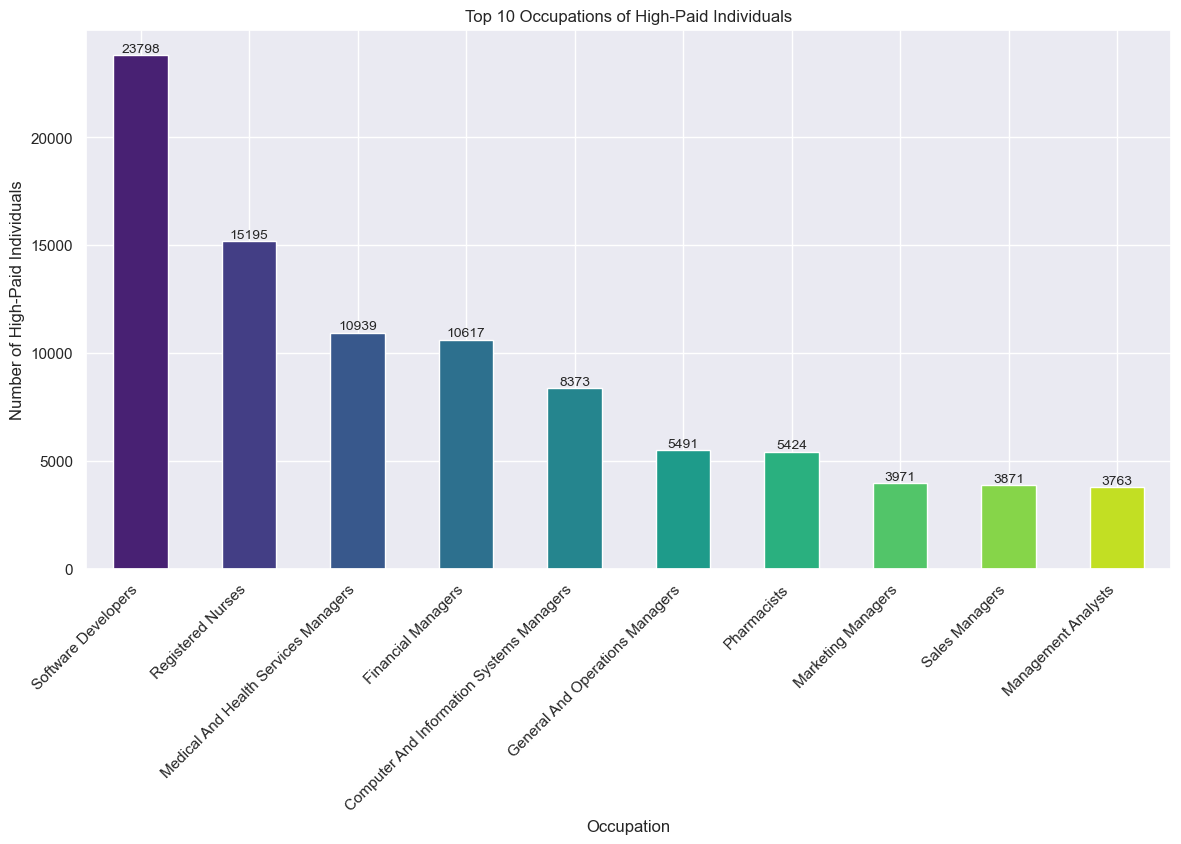

In [ ]:
# Plot 1: Bar plot with a color palette
plt.figure(figsize=(14, 7))
top_occupations = merged_df['Occupation Title'].value_counts().head(10)
colors = sns.color_palette("viridis", len(top_occupations))  # Use a color palette

top_occupations.plot(kind='bar', color=colors)
plt.title('Top 10 Occupations of High-Paid Individuals')
plt.xlabel('Occupation')
plt.ylabel('Number of High-Paid Individuals')
plt.xticks(rotation=45, ha='right')

# Add text labels on top of the bars
for p in plt.gca().patches:
    plt.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=10)

plt.show()

- **Plot 2**: Horizontal bar plot for better readability of occupation names.


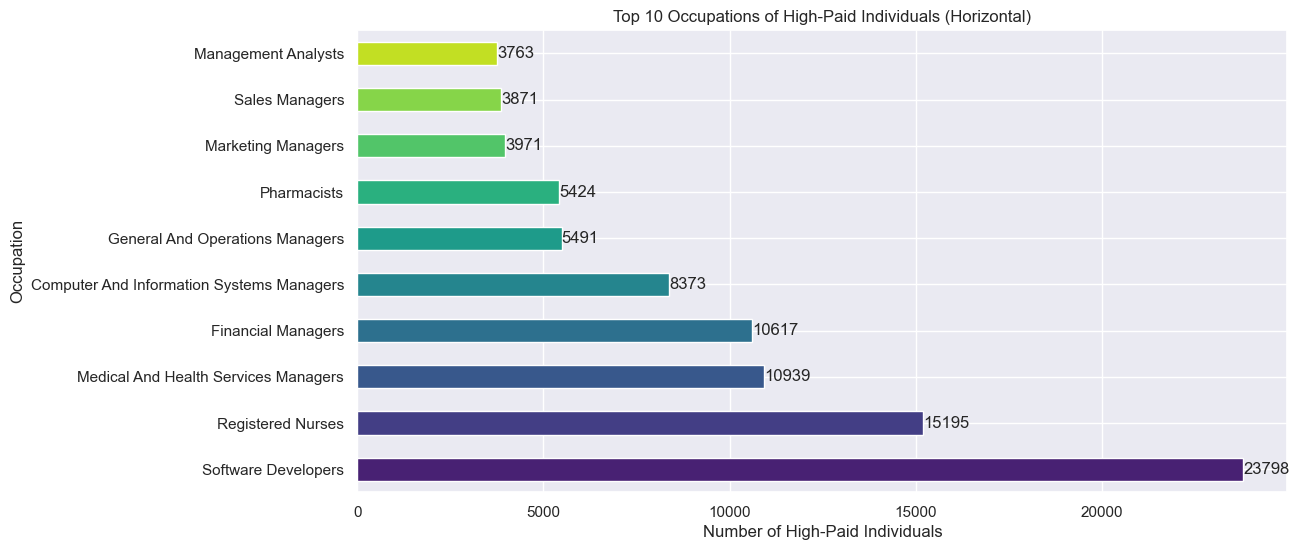

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot 2: Horizontal bar plot with a color palette
plt.figure(figsize=(12, 6))
top_occupations = merged_df['Occupation Title'].value_counts().head(10)

# Use a color palette
colors = sns.color_palette("viridis", len(top_occupations))  # Choose a color palette

top_occupations.plot(kind='barh', color=colors)
plt.title('Top 10 Occupations of High-Paid Individuals (Horizontal)')
plt.xlabel('Number of High-Paid Individuals')
plt.ylabel('Occupation')

# Add text labels on the bars
for index, value in enumerate(top_occupations):
    plt.text(value, index, str(value), va='center')  # Add text labels

plt.show()
plt.savefig('./Images/top_10_OCC_high_paid_indv.png')

Interpretaion :
- Tech Dominance: The top occupations indicate a strong representation from the technology sector, emphasizing its role as a high-paying industry.
Financial Sector Presence: Financial managers' inclusion highlights the importance of financial expertise in driving organizational success.
Management Roles: Both IT and financial management roles underscore the premium paid for leadership positions in specialized fields.
- This visualization reinforces the idea that the highest-paying jobs are often in high-demand, specialized fields like software development and financial management. These sectors require specific skill sets and leadership, which are highly compensated across different regions.

3. What is the relationship between education level and the number of high-paid individuals?

- **Plot 1:** Bar plot showing the number of high-paid individuals by education level.


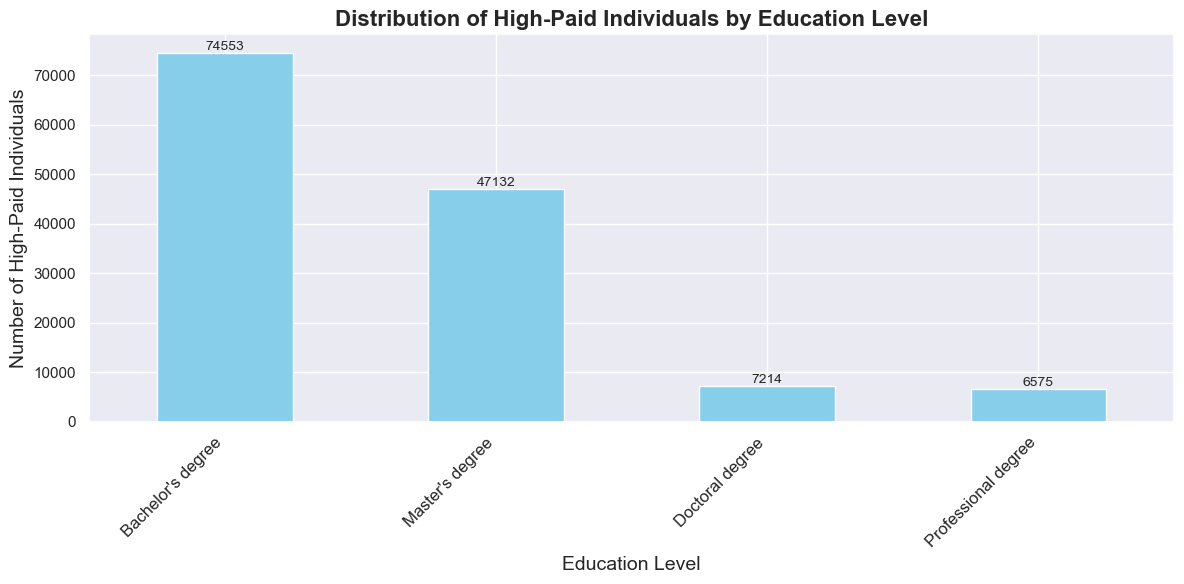

<Figure size 640x480 with 0 Axes>

In [ ]:
# 3. Relationship between education level and high-paid individuals
# Plot 1: Bar plot
plt.figure(figsize=(12, 6))
education_counts = merged_df['Education Level'].value_counts()
education_counts.plot(kind='bar', color='skyblue')

# Title and labels
plt.title('Distribution of High-Paid Individuals by Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Number of High-Paid Individuals', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Adding value annotations on top of the bars
for index, value in enumerate(education_counts):
    plt.text(index, value, str(value), ha='center', va='bottom', fontsize=10)

plt.tight_layout()  # Adjust layout to make room for labels
plt.show()
plt.savefig('./Images/High_paid_by_Education_Level.png')


- **Plot 2:** Box plot showing the distribution of salaries by education level.


C:\Users\marwa\AppData\Local\Temp\ipykernel_18408\1595419866.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education Level', y='Annual Mean Wage', data=merged_df, order=education_order, palette='Set2')


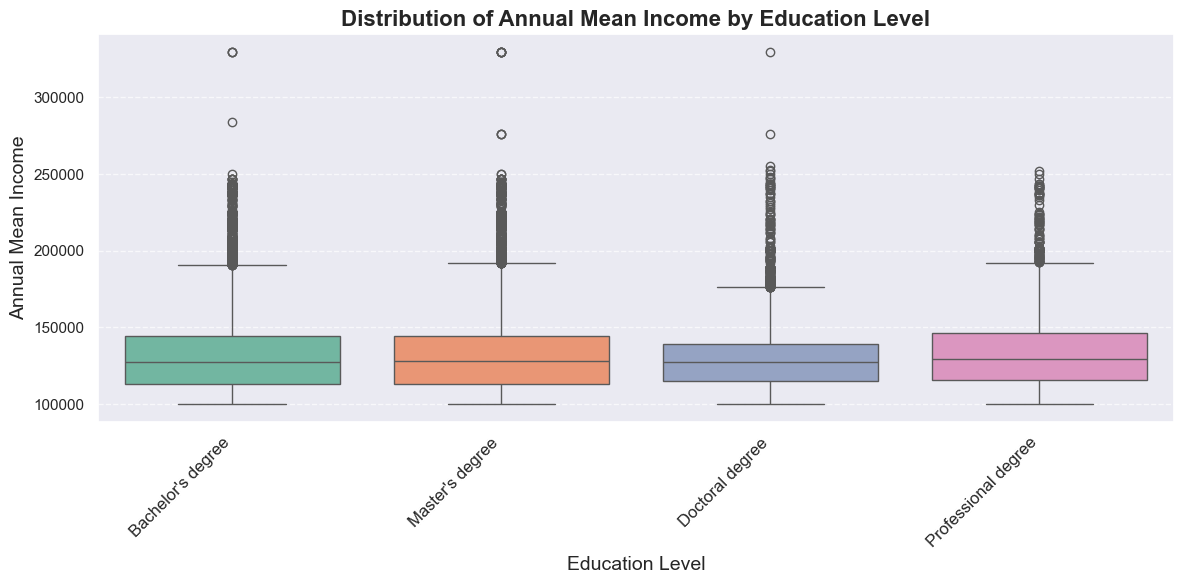

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot 2: Box plot
# Define a custom order for education levels if needed
education_order = merged_df['Education Level'].value_counts().index.tolist()

# Create the box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education Level', y='Annual Mean Wage', data=merged_df, order=education_order, palette='Set2')

# Title and labels
plt.title('Distribution of Annual Mean Income by Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Education Level', fontsize=14)
plt.ylabel('Annual Mean Income', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)

# Adding grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()  # Adjust layout to make room for labels
plt.show()
plt.savefig('./Images/Salary_by_ Education_Level.png')

The high incomes for individuals with "Grade 5 to 8," "Associate Degree," and "Nursing to Grade 4" can be explained by the demand for skilled trades and healthcare roles, which require specialized training rather than a four-year degree. These fields, such as nursing and technical professions, offer high salaries due to expertise, certifications, and the labor market's need for skilled workers

4. What is the correlation between salary (A_MEAN) and other numerical features?


In [ ]:
# Select only numerical columns from the DataFrame
numerical_columns = merged_df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix
correlation_matrix = merged_df[numerical_columns].corr()

# Filter the correlation to show only the correlation of 'A_MEAN' with other numerical features
salary_correlation = correlation_matrix['Annual Mean Wage'].sort_values(ascending=False)

# Display the correlation values
print(salary_correlation)



Annual Mean Wage      1.000000
Hourly Mean Wage      1.000000
Annual Median Wage    0.897382
Hourly Median Wage    0.897377
State Code            0.141394
Total Employment      0.117406
Degree Field Code     0.038504
Age                   0.005263
Education Code        0.004850
State Code 2         -0.168440
Name: Annual Mean Wage, dtype: float64


- **Plot 1:** Heatmap showing the correlation matrix of numerical features.

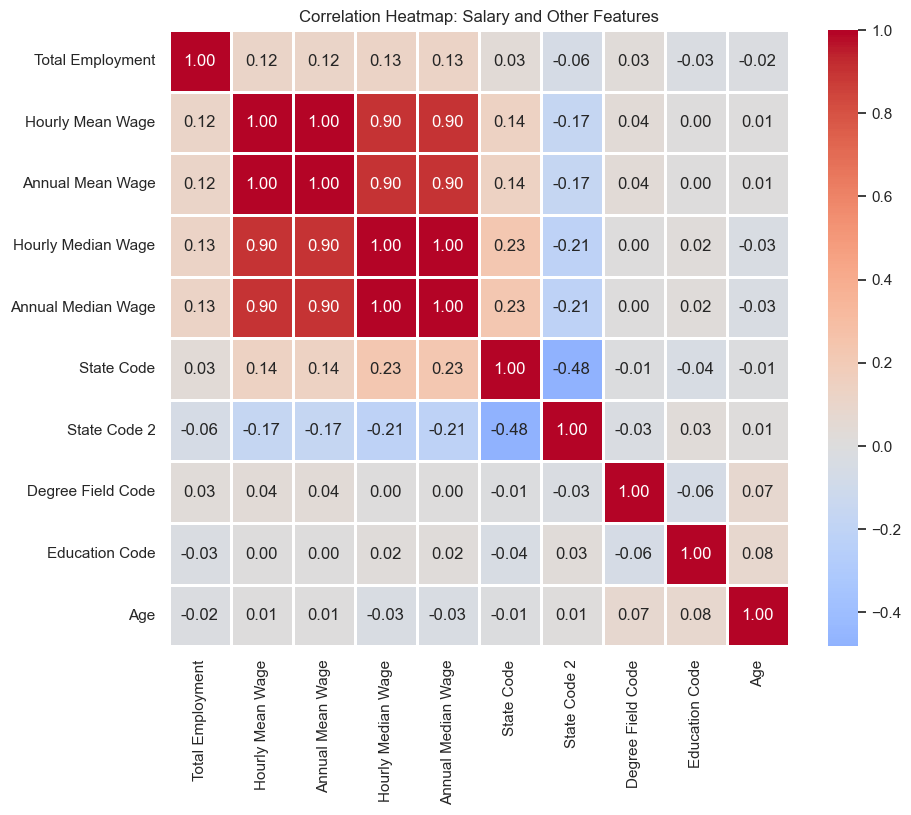

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot heatmap of correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, linewidths=1, linecolor='white', fmt=".2f")
plt.title('Correlation Heatmap: Salary and Other Features')
plt.show()
plt.savefig('./Images/Correlation.png')


The small correlation (max 0.15) suggests that salary is influenced by many factors in complex ways, not just the numerical features. It could be due to non-linear relationships, diverse salary ranges across industries, or the presence of outliers, making it hard to capture strong linear correlations.

- **Plot 2:** Scatter plot showing the relationship between A_MEAN and TOT_EMP.

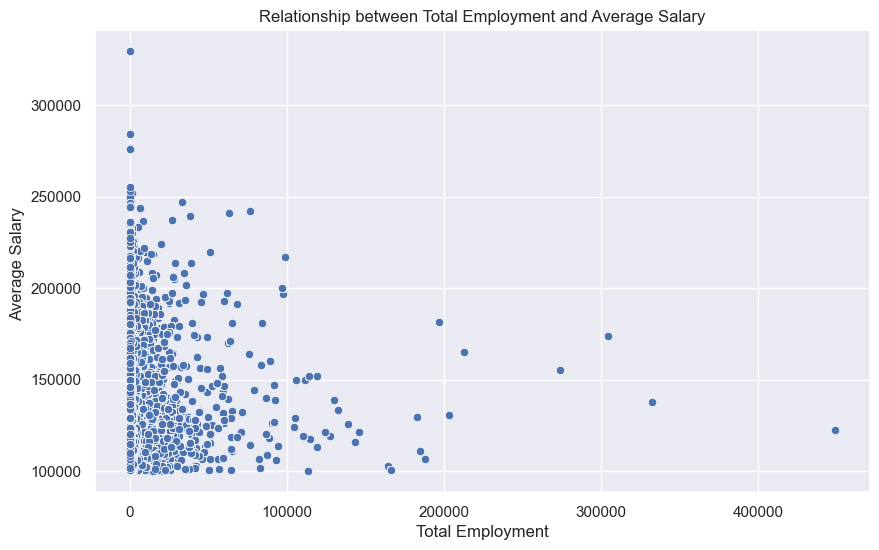

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot 2: Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Employment', y='Annual Mean Wage', data=merged_df)
plt.title('Relationship between Total Employment and Average Salary')
plt.xlabel('Total Employment')
plt.ylabel('Average Salary ')
plt.show()
plt.savefig('./Images/Relationship_between_Total_Employment_and_Average_Salary.png')

5. What is the distribution of high-paid individuals by gender?

- Plot 1: Count of High-Paid Individuals by Gender

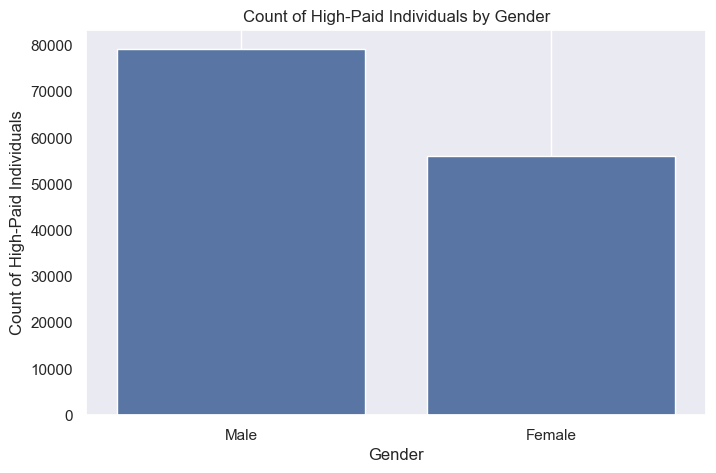

<Figure size 640x480 with 0 Axes>

In [ ]:
# Count of high-paid individuals by gender
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', data=merged_df)
plt.title('Count of High-Paid Individuals by Gender')
plt.xlabel('Gender')
plt.ylabel('Count of High-Paid Individuals')
plt.grid()
plt.show()
plt.savefig('./Images/Count_of_High-Paid_Individuals_by_Gender.png')

- Plot 2: Average Annual Mean Wage by Gender

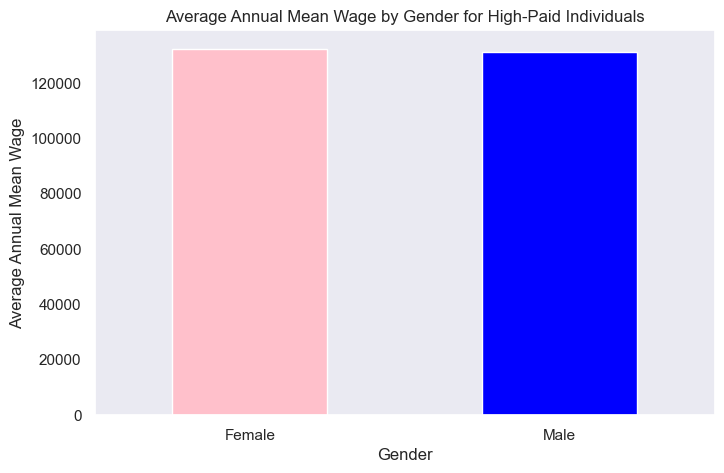

<Figure size 640x480 with 0 Axes>

In [ ]:
# Average Annual Mean Wage by Gender
avg_wages_by_gender = merged_df.groupby('Gender')['Annual Mean Wage'].mean()

plt.figure(figsize=(8, 5))
avg_wages_by_gender.plot(kind='bar', color=['pink', 'blue'])
plt.title('Average Annual Mean Wage by Gender for High-Paid Individuals')
plt.xlabel('Gender')
plt.ylabel('Average Annual Mean Wage')
plt.xticks(rotation=0)
plt.grid()
plt.show()
plt.savefig('./Images/Ave_A_Wage_by_Gender_for_High-Paid_Individuals.png')

The results show that in the count of high-paid individuals by gender, males dominate, which is often reflective of the overall gender disparity in high-paying occupations and leadership roles. This is consistent with many industries where more males are in top-paying positions.

However, in the average annual mean wage by gender, females show a slight dominance, suggesting that within the specific high-paying roles analyzed, women may be earning slightly more on average. This could reflect a few things:

- Differences in Occupations: High-paying jobs for women may be concentrated in fields that offer slightly higher wages.
- Smaller Sample Size for Women: There could be fewer women in the data, but their salaries might skew higher due to fewer women in the job market at the high end.
- Sector Differences: Certain sectors, such as healthcare or education, might have fewer men but offer high-paying opportunities for women, leading to a higher average wage.
>The slight difference in wages might also indicate that the top earners in some fields may be women, even though more men hold high-paying roles in other industries.


6. How does the average salary vary across different occupation?

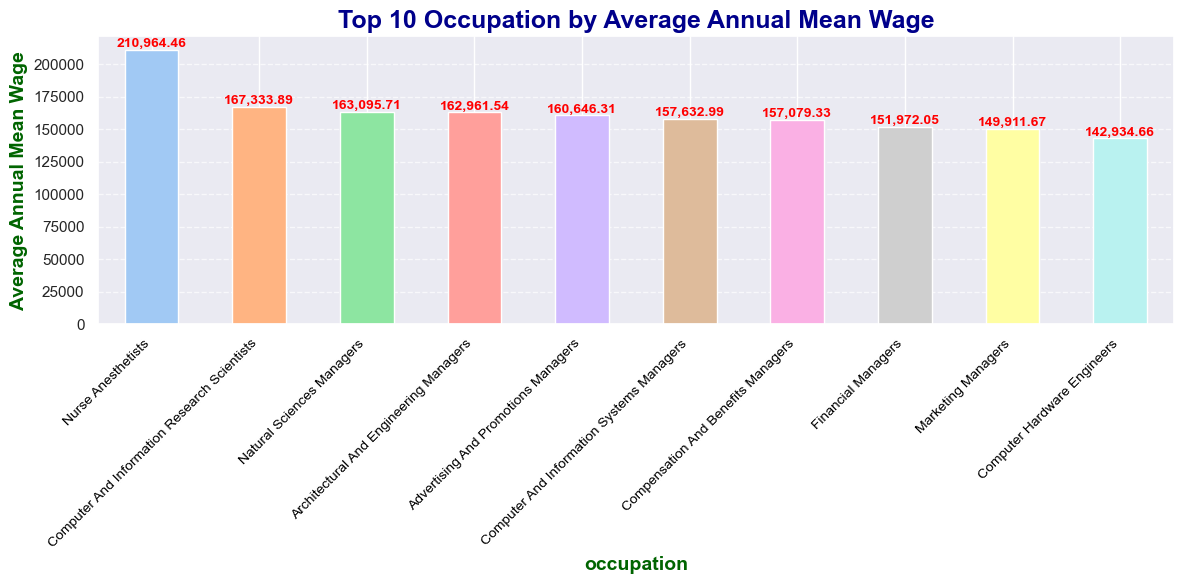

<Figure size 640x480 with 0 Axes>

In [ ]:
# # Average Annual Mean Wage by occupation
# Step 1: Calculate the average annual mean wage for each occupation
avg_wages_by_industry = merged_df.groupby('Occupation Title')['Annual Mean Wage'].mean().sort_values(ascending=False)

# Step 2: Create the bar plot for the top 10 industries
plt.figure(figsize=(12, 6))
bars = avg_wages_by_industry.head(10).plot(kind='bar', color=sns.color_palette("pastel", 10))

# Step 3: Add titles and labels with increased font size and color
plt.title('Top 10 Occupation by Average Annual Mean Wage', fontsize=18, fontweight='bold', color='darkblue')
plt.xlabel('occupation', fontsize=14, fontweight='bold', color='darkgreen')
plt.ylabel('Average Annual Mean Wage', fontsize=14, fontweight='bold', color='darkgreen')
plt.xticks(rotation=45, ha='right', fontsize=10, color='black')  # Reduced fontsize to 10
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Step 4: Add data labels on top of the bars with contrasting color
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():,.2f}', 
                  (bar.get_x() + bar.get_width() / 2, bar.get_height()), 
                  ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

plt.tight_layout()  # Adjust layout to make room for labels
plt.show()
plt.savefig('./Images/Top_10_Occupation_by_Average_Annual_Mean_Wage.png')

C:\Users\marwa\AppData\Local\Temp\ipykernel_18408\2475497747.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupation Title', y='Annual Mean Wage', data=filtered_df, palette='Set2')


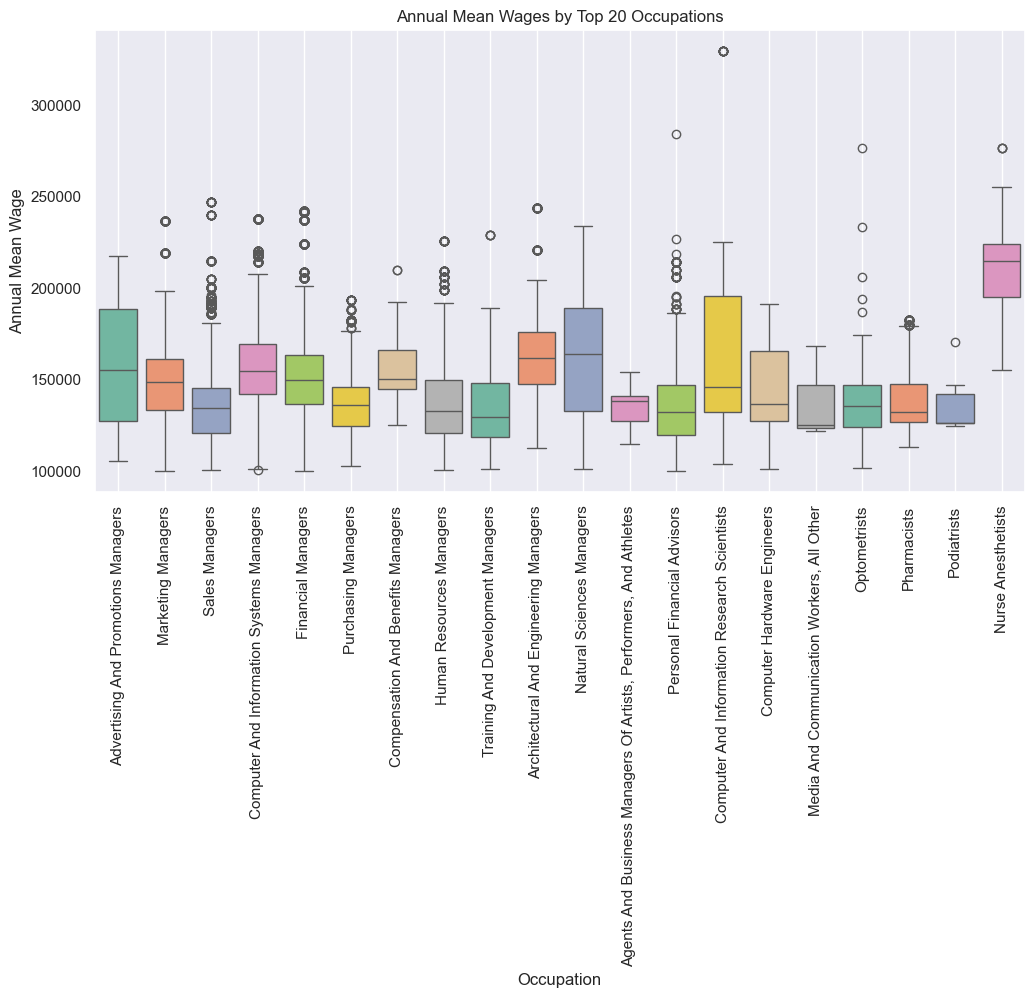

<Figure size 640x480 with 0 Axes>

In [ ]:
# # Boxplot of Annual Mean Wages by OCCupation
# Step 1: Calculate the average annual mean wage for each occupation
avg_wages_by_occupation = merged_df.groupby('Occupation Title')['Annual Mean Wage'].mean().sort_values(ascending=False)
# Step 2: Select the top 20 occupations
top_20_occupations = avg_wages_by_occupation.head(20).index
filtered_df = merged_df[merged_df['Occupation Title'].isin(top_20_occupations)]
# Step 3: Create the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Occupation Title', y='Annual Mean Wage', data=filtered_df, palette='Set2')
plt.xticks(rotation=90)
plt.title('Annual Mean Wages by Top 20 Occupations')
plt.xlabel('Occupation')
plt.ylabel('Annual Mean Wage')
plt.grid()
plt.show()
plt.savefig('./Images/Annual_Mean_Wages_by_Top_20_Occupations.png')

7. How is the distribution of high-paid individuals across different age groups?

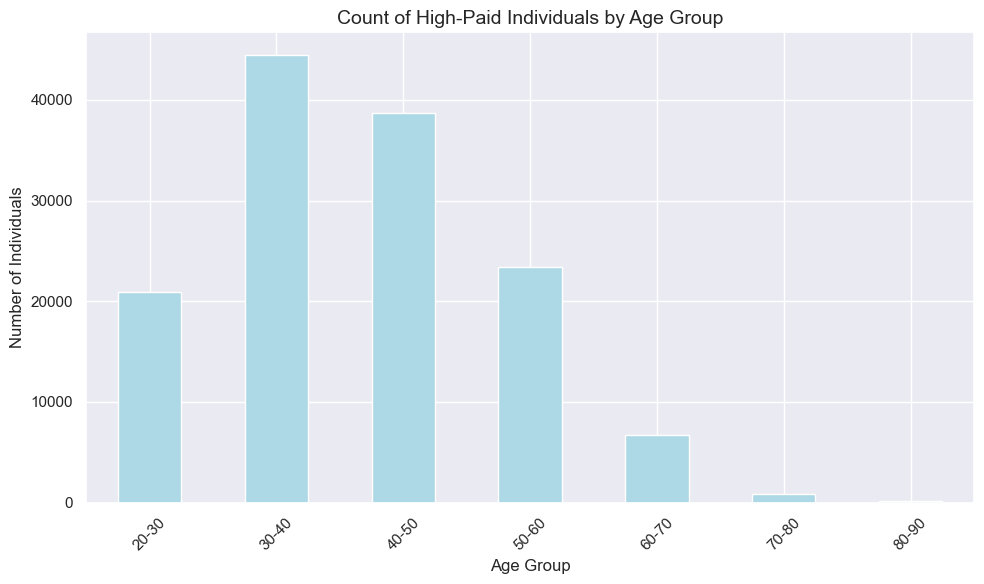

<Figure size 640x480 with 0 Axes>

In [ ]:
# Create age groups for better visualization (e.g., 20-30, 30-40, etc.)
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90']
merged_df['Age_grp'] = pd.cut(merged_df['Age'], bins=bins, labels=labels, right=False)

# Plot 1: Count of High-Paid Individuals by Age Group
plt.figure(figsize=(10, 6))
merged_df['Age_grp'].value_counts().sort_index().plot(kind='bar', color='lightblue')
plt.title('Count of High-Paid Individuals by Age Group', fontsize=14)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.savefig('./Images/High-Paid_Individuals_by_Age_Group.png')